# Bitcoin Price Prediction with TensorFlow: Example Notebook

This notebook demonstrates how to use the utility functions from `bitcoin_utils.py` to:
- Load and clean historical Bitcoin data.
- Engineer technical features.
- Prepare sequences for LSTM modeling.
- Train a simple LSTM network to predict Bitcoin prices.

We keep this example minimal and clean to illustrate usage of the provided API.


### Setup & Imports

In [34]:
import sys
sys.path.append('..')  # if bitcoin_utils.py is in the same folder

# Import utility functions from your module
from bitcoin_utils import (
    load_and_clean_csv,
    update_dataset_with_latest,
    technical_features,
    generate_sequences  # <-- this is the important one
)
from bitcoin_utils import (
    build_lstm_model,
    train_lstm_model,
    plot_training_loss
)
import numpy as np



## Load and Clean Bitcoin Data

We load the dataset from the CSV file and apply initial cleaning and formatting.


In [35]:
# Path to your dataset
csv_path = 'btc-usd-max.csv'  # Update path if needed

# Load and clean
df = load_and_clean_csv(csv_path)

# Show the head
df.head()


INFO:bitcoin_utils:Loading dataset from btc-usd-max.csv


INFO:bitcoin_utils:Dataset loaded: 4391 rows; columns: ['price', 'market_cap', 'total_volume']


,price,market_cap,total_volume
snapped_at,,,
2013-04-28 00:00:00+00:00,135.30,1.500518e+09,0.0
2013-04-29 00:00:00+00:00,141.96,1.575032e+09,0.0
2013-04-30 00:00:00+00:00,135.30,1.501657e+09,0.0
2013-05-01 00:00:00+00:00,117.00,1.298952e+09,0.0
2013-05-02 00:00:00+00:00,103.43,1.148668e+09,0.0


## Update Dataset with Latest Data Point

To ensure we are working with the most recent Bitcoin data, we can use the `update_dataset_with_latest()` function from `bitcoin_utils.py`.

This function:
- Fetches the latest market data from the CoinGecko API.
- Appends the new data point to the existing dataset (if it’s not already present).
- Keeps your CSV file up-to-date automatically.

We then reload the updated dataset to continue working with the latest data.


In [36]:

update_dataset_with_latest(csv_path)

# Reload the updated dataset
df = load_and_clean_csv(csv_path)

# Confirm update
df.tail()

INFO:bitcoin_utils:Loading existing dataset from btc-usd-max.csv
INFO:bitcoin_utils:Fetching latest data point from CoinGecko
INFO:bitcoin_utils:Latest data point: {'snapped_at': Timestamp('2025-05-17 02:59:53+0000', tz='UTC'), 'price': 103239.21365145926, 'market_cap': 2050861350748.3784, 'total_volume': 23923323148.107147}
INFO:bitcoin_utils:Appending new data point to the dataset.
INFO:bitcoin_utils:Dataset updated and saved to btc-usd-max.csv
INFO:bitcoin_utils:Loading dataset from btc-usd-max.csv
INFO:bitcoin_utils:Dataset loaded: 4392 rows; columns: ['price', 'market_cap', 'total_volume']


,price,market_cap,total_volume
snapped_at,,,
2025-05-15 22:53:12+00:00,103647.243066,2.059060e+12,3.167102e+10
2025-05-17 00:24:13+00:00,103497.396716,2.056151e+12,2.578198e+10
2025-05-17 02:13:55+00:00,102934.168482,2.044967e+12,2.402542e+10
2025-05-17 02:25:53+00:00,103012.113000,2.044974e+12,2.396987e+10
2025-05-17 02:59:53+00:00,103239.213651,2.050861e+12,2.392332e+10


# Exploratory Data Analysis (EDA)

In this section, we explore the Bitcoin dataset to understand trends, patterns, and relationships between variables.


1️⃣ Line Plot: Bitcoin Price Over Time


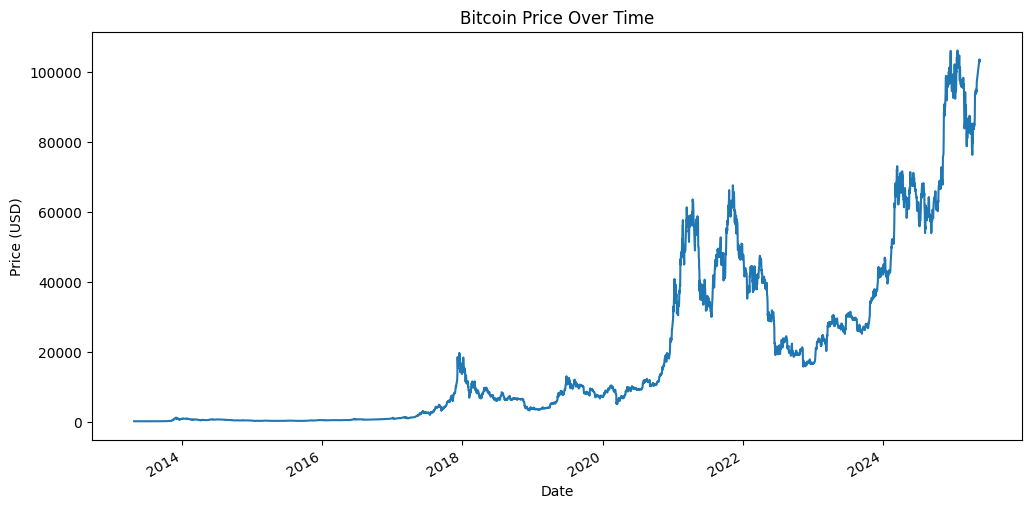

In [37]:
import matplotlib.pyplot as plt

# Plot Bitcoin price over time
plt.figure(figsize=(12,6))
df['price'].plot()
plt.title('Bitcoin Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()


2️⃣ Log Scale Price Plot


Bitcoin price spans many orders of magnitude; a log plot can be insightful:


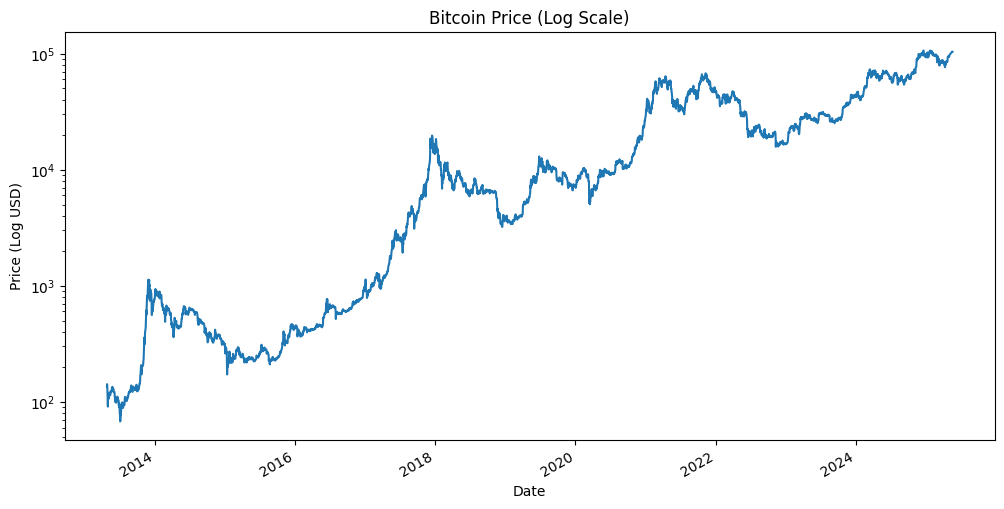

In [38]:
plt.figure(figsize=(12,6))
df['price'].plot(logy=True)
plt.title('Bitcoin Price (Log Scale)')
plt.xlabel('Date')
plt.ylabel('Price (Log USD)')
plt.show()


3️⃣ Volume vs. Price (Scatter Plot)

Shows relationship between trading volume and price.

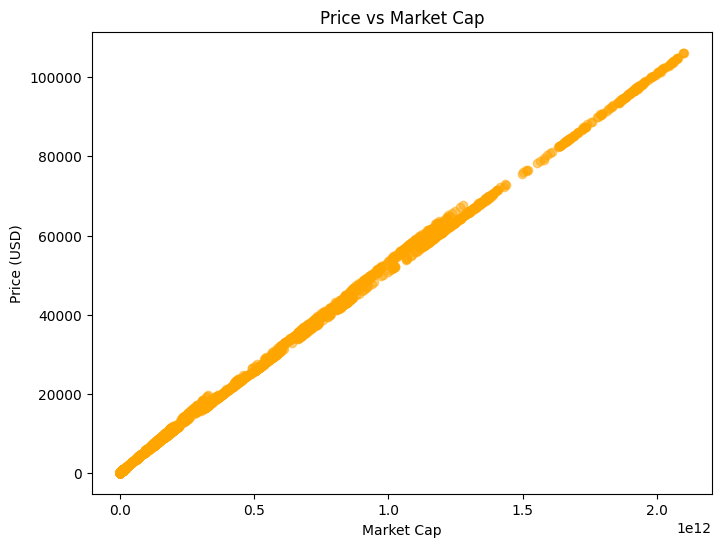

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(df['market_cap'], df['price'], alpha=0.5, color='orange')
plt.title('Price vs Market Cap')
plt.xlabel('Market Cap')
plt.ylabel('Price (USD)')
plt.show()


5️⃣ Simple Moving Average (SMA)

You can overlay moving averages to show trends.

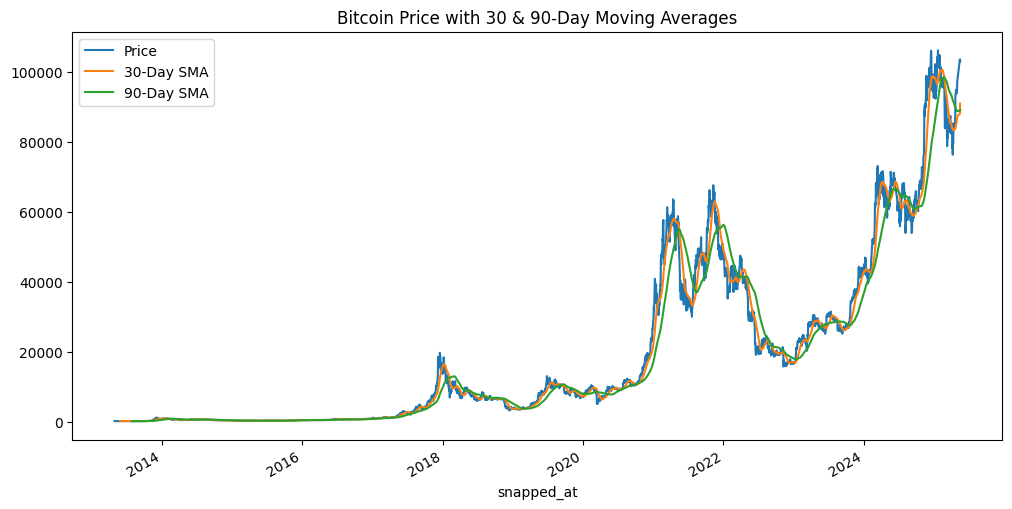

In [40]:
df['SMA_30'] = df['price'].rolling(window=30).mean()
df['SMA_90'] = df['price'].rolling(window=90).mean()

plt.figure(figsize=(12,6))
df['price'].plot(label='Price')
df['SMA_30'].plot(label='30-Day SMA')
df['SMA_90'].plot(label='90-Day SMA')
plt.title('Bitcoin Price with 30 & 90-Day Moving Averages')
plt.legend()
plt.show()


## Add Technical Features

We enrich the dataset with useful features like returns, moving averages, and lag features.


In [41]:
# Add engineered features
df = technical_features(df)

# Drop rows with NaNs in any input feature or the target
df = df.dropna(subset=features + ['price'])
# Check the result
df.tail()

INFO:bitcoin_utils:Adding technical feature columns
INFO:bitcoin_utils:Feature engineering complete


,price,market_cap,total_volume,SMA_30,SMA_90,returns,SMA_7,volatility_7,volatility_30,lag_1day
snapped_at,,,,,,,,,,
2025-05-15 22:53:12+00:00,103647.243066,2.059060e+12,3.167102e+10,88024.453323,88881.233618,0.067008,96461.176904,3449.935958,6793.317343,97138.185077
2025-05-17 00:24:13+00:00,103497.396716,2.056151e+12,2.578198e+10,88679.299626,88903.795130,-0.001446,97845.185317,4092.271830,7304.848695,103647.243066
2025-05-17 02:13:55+00:00,102934.168482,2.044967e+12,2.402542e+10,89323.909058,88957.303233,-0.005442,98974.265607,4272.631347,7684.193733,103497.396716
2025-05-17 02:25:53+00:00,103012.113000,2.044974e+12,2.396987e+10,90150.596705,89028.739079,0.000757,100225.087541,3929.078695,7780.915467,102934.168482
2025-05-17 02:59:53+00:00,103239.213651,2.050861e+12,2.392332e+10,90952.594085,89102.114578,0.002205,101511.296161,3007.170867,7850.726077,103012.113000


In [42]:
features = ['price', 'returns', 'SMA_7', 'SMA_30', 'volatility_7', 'volatility_30', 'lag_1day']
X, y, scaler_X, scaler_y = generate_sequences(df, features=features, target='price', window_size=60)


# Now safely generate sequences


print("X shape:", X.shape)
print("y shape:", y.shape)
print("Any NaN in X?", np.isnan(X).any())
print("Any NaN in y?", np.isnan(y).any())
print("X min/max:", X.min(), X.max())
print("y min/max:", y.min(), y.max())




INFO:bitcoin_utils:Generating sequences using features ['price', 'returns', 'SMA_7', 'SMA_30', 'volatility_7', 'volatility_30', 'lag_1day'] and target 'price'
INFO:bitcoin_utils:Generated 4303 sequences with shape (60, 7)


X shape: (4303, 60, 7)
y shape: (4303, 1)
Any NaN in X? False
Any NaN in y? False
X min/max: 0.0 1.0000000000000002
y min/max: 0.0002468655821656128 0.9999999999999999


In [43]:
# Generate sequences for modeling
X, y, scaler_X, scaler_y = generate_sequences(df, features=features, target='price', window_size=60)

INFO:bitcoin_utils:Generating sequences using features ['price', 'returns', 'SMA_7', 'SMA_30', 'volatility_7', 'volatility_30', 'lag_1day'] and target 'price'
INFO:bitcoin_utils:Generated 4303 sequences with shape (60, 7)


## Build and Train LSTM Model

We build a simple LSTM model to predict Bitcoin prices based on historical data.


In [44]:
# Split data into train/test sets (e.g., 80% train, 20% test)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [45]:
model = build_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]))
model, history = train_lstm_model(model, X_train, y_train, X_test, y_test)


INFO:bitcoin_utils:Building LSTM model with input shape (60, 7)
INFO:bitcoin_utils:Training LSTM model for 50 epochs with batch size 32


Epoch 1/50
108/108 [==============================] - 6s 35ms/step - loss: 0.0020 - val_loss: 0.0069
Epoch 2/50
108/108 [==============================] - 3s 31ms/step - loss: 8.7263e-04 - val_loss: 0.0056
Epoch 3/50
108/108 [==============================] - 3s 32ms/step - loss: 8.2381e-04 - val_loss: 0.0016
Epoch 4/50
108/108 [==============================] - 3s 31ms/step - loss: 6.7701e-04 - val_loss: 9.2009e-04
Epoch 5/50
108/108 [==============================] - 5s 45ms/step - loss: 6.5944e-04 - val_loss: 8.3736e-04
Epoch 6/50
108/108 [==============================] - 3s 30ms/step - loss: 5.8189e-04 - val_loss: 0.0015
Epoch 7/50
108/108 [==============================] - 3s 29ms/step - loss: 6.3234e-04 - val_loss: 0.0022
Epoch 8/50
108/108 [==============================] - 3s 29ms/step - loss: 5.2919e-04 - val_loss: 0.0061
Epoch 9/50
108/108 [==============================] - 3s 29ms/step - loss: 4.9012e-04 - val_loss: 0.0011
Epoch 10/50
108/108 [==============================

INFO:bitcoin_utils:Model training complete.


## Visualize Model Performance

We plot the training and validation loss to observe how the model learns.


INFO:bitcoin_utils:Plotting training and validation loss.


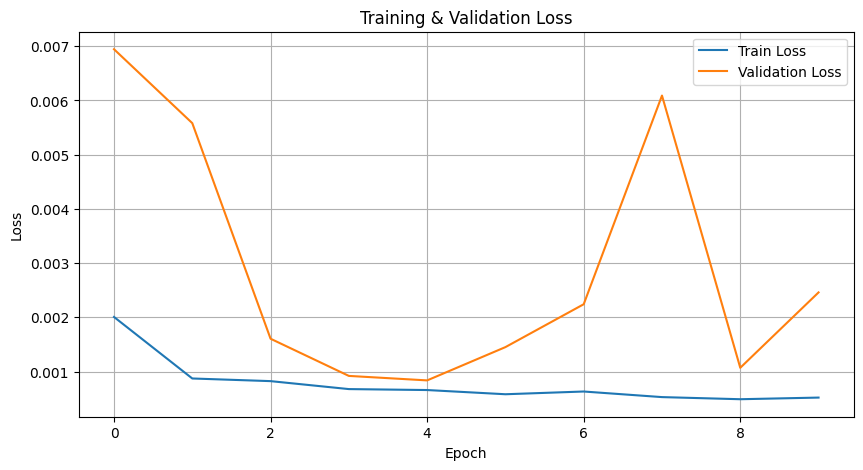

In [47]:
plot_training_loss(history)

